<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>
<div style="background-color: #1A5276; padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Building Applications with Foundation Models</h1>
    <h2 style="color: white; margin-top: 15px;">Lab 1: LangChain Modules</h2>
</div>

This notebook demonstrates how to use pre-trained Large Language Models (LLM) for text generation. LLMs are trained on massive amounts of data, making them capable of solving several NLP tasks.
[LangChain](https://python.langchain.com/docs/get_started/introduction#get-started) offers several modules that simplify the use of LLMs for inference. In this notebook, we will use LangChain's prompt templates to effectively solve different tasks with minimal lift.


<!-- Table of Contents with All Section Levels -->
<div id="section0" style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2874A6; border-bottom: 1px solid #2874A6; padding-bottom: 5px;">Table of contents</h2>
    <p><a href="#section1" style="color: #2E86C1; font-weight: bold; text-decoration: none;">1. Setup and configuration</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section1-1" style="color: #3498DB; text-decoration: none;">1.1 Install and import dependencies</a></li>
        <li><a href="#section1-2" style="color: #3498DB; text-decoration: none;">1.2 Validate LLM model access</a>
        <li><a href="#section1-3" style="color: #3498DB; text-decoration: none;">1.3. Using Amazon Bedrock for inference</a>
        </li>
    </ul>
    <p><a href="#section2" style="color: #2E86C1; font-weight: bold; text-decoration: none;">2. Prompt templates</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section2-1" style="color: #3498DB; text-decoration: none;">2.1 <tt>PromptTemplate</tt> with variable number of inputs</a>
        </li>
    </ul>
    <p><a href="#section3" style="color: #2E86C1; font-weight: bold; text-decoration: none;">3. Output parsers</a></p>
    <p><a href="#section4" style="color: #2E86C1; font-weight: bold; text-decoration: none;">4. Chains</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section4-1" style="color: #3498DB; text-decoration: none;">4.1 Chains with LCEL</a></li>
        <li><a href="#section4-2" style="color: #5DADE2; text-decoration: none;">4.2 Connecting multiple elements together</a></li>
        <li><a href="#section4-3" style="color: #3498DB; text-decoration: none;">4.3 Sequential chains with multiple inputs</a></li>
    </ul>
    <p><a href="#section5" style="color: #2E86C1; font-weight: bold; text-decoration: none;">5. Quizzes</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
</div>

<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About this Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>    

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">1. Setup and configuration</h2>
</div>
(<a href="#section0">Go to top</a>)


<!-- Subsection Header -->
<div id="section1-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.1 Install and import dependencies</h3>
</div>

First, let's install and import the necessary libraries, including the [LangChain](https://python.langchain.com/docs/how_to/installation/) library.

In [ ]:
%%capture
!pip install -r ../requirements.txt --quiet

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
import boto3
import pandas as pd
from IPython.display import Markdown

sys.path.append('..')

<!-- Subsection Header -->
<div id="section1-2" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.2 Validate LLM model access</h3>
</div>
(<a href="#0">Go to top</a>)

As a first step, we need to verify that the LLM models required in this lab are accessible.  Let's do that now by using the helper function `validate_models_access` and provide the list of LLM models that we require for this lab.  If the call to `validate_models_access` returns any model ids in the output list, then you will need to go to the `Amazon Bedrock` console and enable access to the required models.

In [ ]:
from mlu_utils.helpers import validate_models_access
if not validate_models_access(["amazon.nova-lite-v1:0", "mistral.mixtral-8x7b-instruct-v0:1"]):
    print("The models are accessible. You can go ahead running this notebook.")

<!-- Subsection Header -->
<div id="section1-3" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.3 Using Amazon Bedrock for inference</h3>
</div>

[Amazon Bedrock](https://aws.amazon.com/bedrock/) is a fully managed service that offers a choice of high-performing foundation models (FMs) from leading AI companies like [AI21 Labs](https://www.ai21.com/), [Anthropic](https://www.anthropic.com/), [Cohere](https://cohere.com/), [Meta](https://ai.meta.com/), [Stability AI](https://stability.ai/), and [Amazon](https://aws.amazon.com/bedrock/titan/) with a single API, along with a broad set of capabilities to build generative AI applications, simplifying development while maintaining privacy and security.
Amazon Bedrock is serverless, which means that you don't have to manage any infrastructure and simply use and integrate the LLMs hosted on the platform  within applications.

In this workshop, we will primarily use LLMs through Bedrock APIs. 

Each model hosted on Amazon Bedrock has a different set of inference parameters. Please refer this [page](https://docs.aws.amazon.com/bedrock/latest/userguide/model-parameters.html) to identify the inference parameters for the selected LLM. The [Converse API](https://docs.aws.amazon.com/bedrock/latest/APIReference/API_runtime_Converse.html) in Amazon Bedrock provides a consistent interface for sending messages to various AI models and running inference on them.

**Please opt for frugal practices when using Amazon Bedrock, such as using smaller LLMs for simpler tasks and only reserving the use of the larger LLMs for more complex use cases.**

---

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <img src="../mlu_utils/images/activity.png" alt="Activity" width="200px" style="margin-right: 15px;">
    <div>
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Prompting LLMs</h4>
        <p>Try different prompts and observe the responses generated by the model.</p>
    </div>
</div>

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> Results may not be factually accurate and may be based on false assumptions.</p>
</div>

In [ ]:
from langchain_aws import ChatBedrockConverse
from langchain_core.output_parsers import StrOutputParser

bedrock_llm = ChatBedrockConverse(
    model="amazon.nova-lite-v1:0",
    temperature=0,
    max_tokens=None,
)

In [ ]:
Markdown(bedrock_llm.invoke("What is the capital of Spain?").content)

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">2. Prompt templates</h2>
</div>
(<a href="#section0">Go to top</a>)

The input to the LLM (or any foundational model) is called a __prompt__. Prompts are typically in the form of text. They provide the LLM with all the necessary information to produce the respective response.

__Prompt templates__ are parameterized model inputs serving as pre-defined recipes for LLMs. These templates can be reusable and enable LLMs to adapt to more number of tasks with minimal effort.

<div>
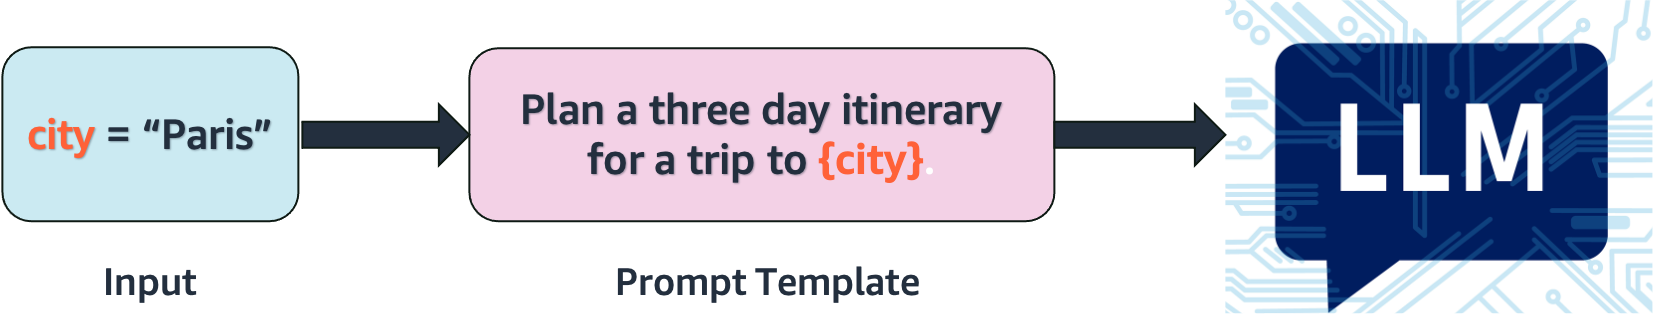
</div>

In [ ]:
from langchain.prompts import PromptTemplate

template = """
You are a travel agent specialized in planning activities for tourists.
Plan a three day itenerary for a trip to {city}.
"""

# Define the prompt template from the string. The input variables are automatically inferred
prompt_template = PromptTemplate.from_template(template)

# Create the prompt for the LLM by setting the input variable
prompt_message = prompt_template.format(city="Paris")
print("Prompt: {}".format(prompt_message))

In [ ]:
# Use the text generation pipeline to generate the response
prompt_template_response = bedrock_llm.invoke(prompt_message)

# Printing the response in a favorable format
Markdown(prompt_template_response.content)

<!-- Subsection Header -->
<div id="section2-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">2.1 Prompt templates with variable number of inputs</h3>
</div>

We can use multiple inputs while defining a prompt template. 
Note that when using multiple inputs, the input keys should match the keys in the prompt template.

<div>
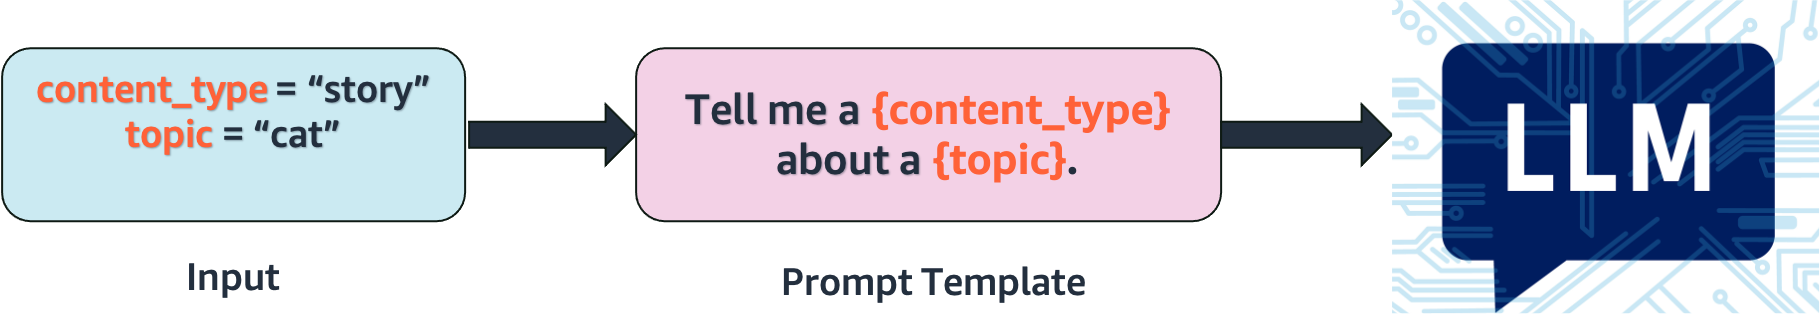
</div>

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <div style="display: flex; align-items: flex-start;">
        <div style="flex: 0 0 200px; margin-right: 15px;">
            <img src="../mlu_utils/images/activity.png" alt="Activity" width="200px" style="max-width: 100%;">
        </div>
        <div style="flex: 1;">
            <h4 style="color: #2874A6; margin-top: 0;">Activity: Interactive prompt template tool</h4>
            <p>Try to create prompt templates in the tool using the following techniques and examine how LLMs can be dynamically prompted:</p>
            <ul>
                <li>Define the variables in the prompt using <tt>{ }</tt></li>
                <li>Set the variable names in the field below.</li>
                <li>Click 'Generate Response' to prompt the LLM with the formated prompt</li>
            </ul>
            <h4 style="color: #2874A6; margin-top: 15px;">Example to try:</h4>
            <p>Copy this template into the widget:</p>
            <pre style="background-color: #f8f9fa; padding: 10px; border-radius: 4px;">Write a {length} {genre} story about {character} who discovers {discovery} in {setting}.</pre>
            <p>Then fill in the variables with values like:</p>
            <ul>
                <li><strong>length</strong>: short</li>
                <li><strong>genre</strong>: science fiction</li>
                <li><strong>character</strong>: a curious teenager</li>
                <li><strong>discovery</strong>: an ancient alien artifact</li>
                <li><strong>setting</strong>: an abandoned subway station</li>
            </ul>
            <p>Try changing the variables to see how the model's response changes. Then create your own template to experiment with!</p>
        </div>
    </div>
</div>

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> Amazon Bedrock employs guardrails which may prevent the model from generating reponses from sensitive, toxic or harmful prompts.</p>
</div>

In [ ]:
from mlu_utils.widgets.prompt_template import create_prompt_interface
prompt_interface = create_prompt_interface(bedrock_llm)
display(prompt_interface)

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">3. Output parsers</h2>
</div>
(<a href="#section0">Go to top</a>)


Output parsers help transform the raw text responses from LLMs into structured formats that are easier to work with programmatically. Instead of having to manually parse text responses, output parsers provide a standardized way to convert LLM outputs into specific data structures like dictionaries, lists, or custom objects.

There are many output parsers available in LangChain. Here is a table with a few of them:

| Name | Description | Output Type |
|------|-------------|-------------|
| JSONOutputParser | Returns a JSON object as specified. You specify a Pydantic model and it will return JSON for that model. Probably the most reliable output parser for getting structured data that does NOT use function calling. | JSON object |
| XMLOutputParser | Returns a dictionary of tags. Use when XML output is needed. Use with models that are good at writing XML (like Anthropic's). | dict |
| CSVOutputParser | Returns a list of comma separated values. | List[str] |
| RetryWithErrorOutputParser | Wraps another output parser. If that output parser errors, then this will pass the original inputs, the bad output, and the error message to an LLM and ask it to fix it. Compared to OutputFixingParser, this one also sends the original instructions. | N/A |
| PydanticOutputParser | Takes a user defined Pydantic model and returns data in that format. | pydantic.BaseModel |
| YAMLOutputParser | Takes a user defined Pydantic model and returns data in that format. Uses YAML to encode it. | pydantic.BaseModel |
| PandasDataFrameOutputParser | Useful for doing operations with pandas DataFrames. | dict |
| EnumOutputParser | Parses response into one of the provided enum values. | Enum |
| DatetimeOutputParser | Parses response into a datetime string. | datetime.datetime |
| StructuredOutputParser | An output parser that returns structured information. It is less powerful than other output parsers since it only allows for fields to be strings. This useful when you are working with smaller LLMs. | Dict[str, str] |

In [ ]:
from langchain_core.output_parsers import JsonOutputParser
import json

# Set up the parser
parser = JsonOutputParser()

template = """
Generate a JSON text describing a fictional character with the following attributes:
- name
- age
- profession
- hobbies (as an array)
- address (as a nested object with street, city, and country)

{format_instructions}
"""

prompt = PromptTemplate(
    template=template,
    input_variables=[],
    partial_variables={"format_instructions": parser.get_format_instructions()}
)

# Generate and parse the output
output = bedrock_llm.invoke(prompt.format()).content
result = parser.parse(output)

# Print the entire JSON structure
print("Full JSON output:")
print(json.dumps(result, indent=2))

In [ ]:
Markdown(output)

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Experimenting with JSON output parsers</h4>
        <p>Use this interactive widget to explore how output parsers transform LLM responses into structured data.</p>
        <ul>
            <li>Examine the template that includes <code>{format_instructions}</code> &mdash; this is where the parser inserts guidance for the LLM</li>
            <li>Click "Generate JSON" to see how the LLM produces structured JSON following the parser's instructions</li>
            <li>Try modifying the template to request different JSON structures (e.g., add new fields, change data types, create deeper nested objects)</li>
            <li>Notice how the parser handles the conversion from raw text to a proper Python dictionary</li>
        </ul>
    </div>
</div>

In [ ]:
from mlu_utils.widgets.json_output_parser_widget import JsonParserUI
json_ui = JsonParserUI(llm=bedrock_llm)
json_ui.display()

<!-- Section Header -->
<div id="section4" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">4. Chains</h2>
</div>
(<a href="#section0">Go to top</a>)

---
Chains are the most basic building block chain. The simplest chain takes in a prompt template, formats it with the user input, and returns the response from an LLM.

<div>
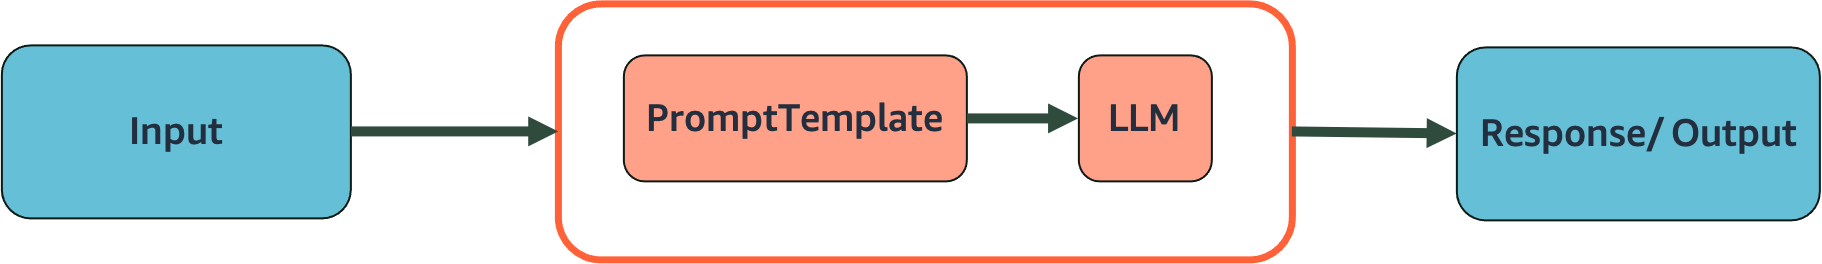
</div>

Let's use a prompt template from the lab and embed it into a simple chain.

<!-- Subsection Header -->
<div id="section4-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">4.1 Chains with LCEL</h3>
</div>

[LandChain Expression Language (LCEL)](https://python.langchain.com/docs/concepts/lcel/) is a powerful way to compose LangChain components together into processing pipelines or "chains." It uses the pipe operator (`|`) to connect components, creating a clean, readable flow of data transformation.

With LCEL, you can:
- Build complex chains with minimal code
- Easily combine prompts, models, and parsers
- Create reusable components that can be mixed and matched
- Process inputs through multiple stages of transformation

The pipe operator (`|`) passes the output from one component as input to the next component in the chain. This functional approach makes it easy to understand the flow of data and to modify chains by adding, removing, or swapping components.

In the example below, we create a simple chain that:
1. Takes a topic and audience as input
2. Formats them into a prompt using a `PromptTemplate`
3. Sends the formatted prompt to our Amazon Bedrock LLM
4. Parses the output as a string using `StrOutputParser`

In [ ]:
from langchain_core.output_parsers import StrOutputParser

explanation_prompt = PromptTemplate.from_template("Explain {topic} to {audience}")

explanation_chain = explanation_prompt | bedrock_llm | StrOutputParser()

explanation_response = explanation_chain.invoke(
    {
        "topic" : "Astrophysics",
        "audience" : "kids"
    }
)

Markdown(explanation_response)

<!-- Sub-subsection Header -->
<div id="section4-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #3498DB;">4.2 Connecting multiple elements together</h3>
</div>

LCEL allows you to build sophisticated processing pipelines by connecting multiple components and chains together. This enables you to create workflows where the output of one chain becomes the input to another, or where multiple chains feed into a single downstream component.

Key features demonstrated in this example:

- **Chain reuse**: We're reusing our previously defined `explanation_chain` as a component in a new chain
- **Input mapping**: The `{"explanation": explanation_chain}` syntax creates a mapping where the output of `explanation_chain` is assigned to the `explanation` variable
- **Nested processing**: The first chain generates an explanation, which is then analyzed by the second chain
- **Single invocation**: Despite having multiple processing steps, we can invoke the entire workflow with a single call

This pattern is extremely powerful for creating multi-step reasoning processes, where an LLM first generates content and then evaluates or transforms its own output in subsequent steps.

In [ ]:
analysis_prompt = PromptTemplate.from_template("Does the explaination talk about our solar system? {explanation}")

analysis_chain = {"explanation": explanation_chain} | analysis_prompt | bedrock_llm | StrOutputParser()

analysis_response = analysis_chain.invoke(
    {
        "topic" : "Astrophysics",
        "audience" : "kids"
    }
)

Markdown(analysis_response)

<!-- Subsection Header -->
<div id="section4-3" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">4.3 Sequential chains with multiple inputs</h3>
</div>

We can also connect multiple chains together. This makes the workflow more complex by allowing a chain to take multiple inputs and pass along multiple outputs. For the next example, we will connect multple chains to allow the information the flow in a structured way. 
When dealing with multiple inputs and outputs, it is important to name the input and output keys.

<div>
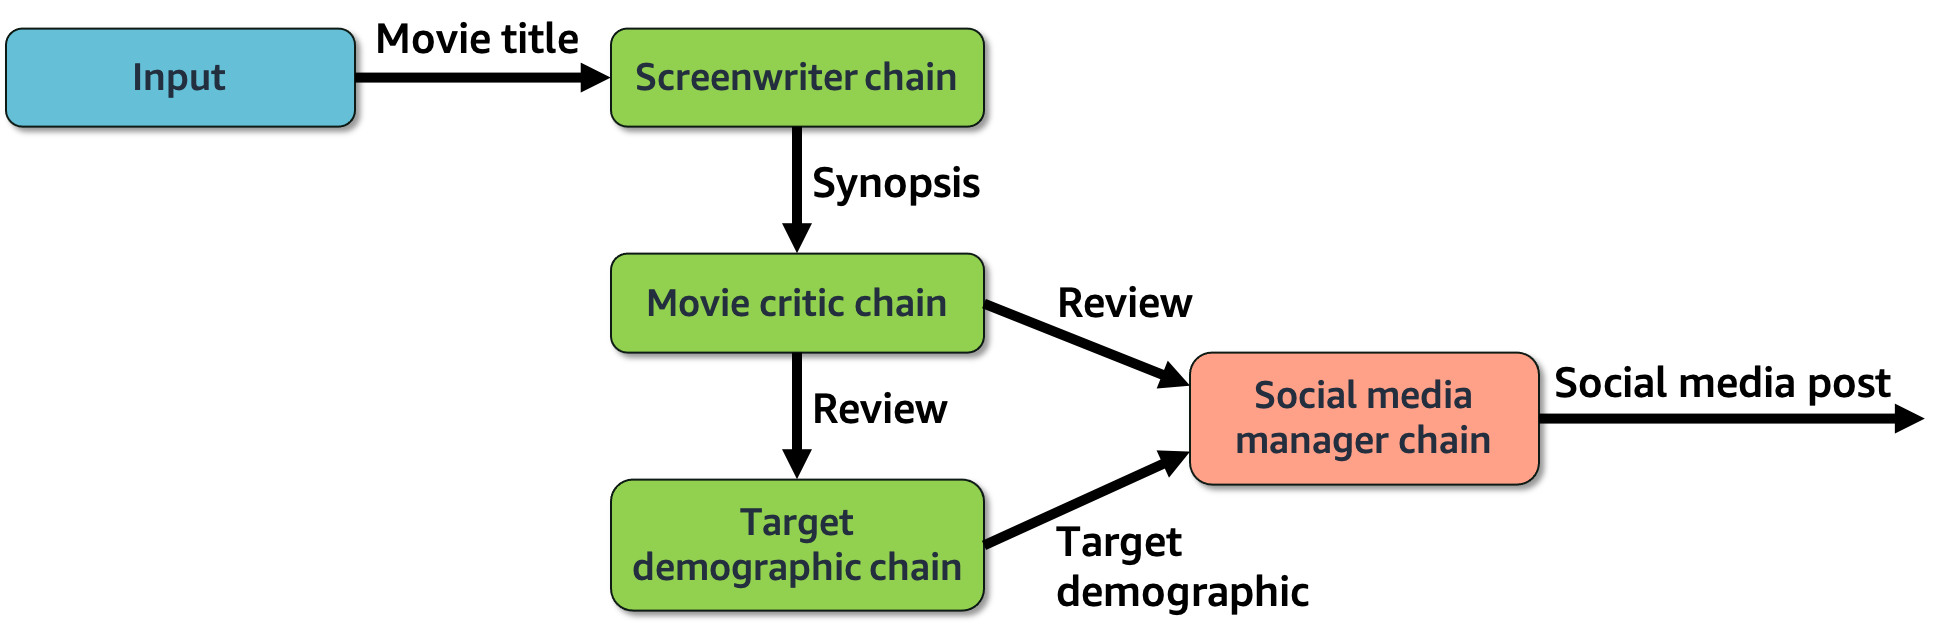
</div>

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

# The prompts remain the same
screenwriter_prompt = PromptTemplate.from_template(
    """
You are a screenwriter. Given the title of the movie, it is your job to write a synopsis for that movie. 
Title: {title}"""
)

movie_critic_prompt = PromptTemplate.from_template(
    """
You are a movie critic from IMDB. Given the synopsis of the movie, it is your job to write a review of that movie. Be precise.
Synopsis: {synopsis}"""
)

target_demographic_prompt = PromptTemplate.from_template(
    """
Based on the critic review, suggest the target demographic for the movie. Be precise.
Critic Review: {review}"""
)

social_media_manager_prompt = PromptTemplate.from_template(
    """
You are a social media manager for a production company. You need to write a short social media post that appeals to the given target demographic given the movie critic review.
The social media post should mention the rating if it is more than three.
Target demographic: {target_demographic}
Critic review: {review}"""
)

# Create individual chains with runnables
screenwriter_chain = screenwriter_prompt | bedrock_llm | StrOutputParser()
movie_critic_chain = movie_critic_prompt | bedrock_llm | StrOutputParser()
target_demographic_chain = target_demographic_prompt | bedrock_llm | StrOutputParser()
social_media_manager_chain = social_media_manager_prompt | bedrock_llm | StrOutputParser()

# Implement the sequential chain using runnables
runnable_sequential_chain = (
    # Start with the input
    RunnableParallel({"title": RunnablePassthrough()})
    # Generate synopsis and keep the title
    .assign(synopsis=lambda x: screenwriter_chain.invoke({"title": x["title"]}))
    # Generate review and keep previous outputs
    .assign(review=lambda x: movie_critic_chain.invoke({"synopsis": x["synopsis"]}))
    # Generate target demographic and keep previous outputs
    .assign(target_demographic=lambda x: target_demographic_chain.invoke({"review": x["review"]}))
    # Generate social media post and keep all previous outputs
    .assign(social_media_post=lambda x: social_media_manager_chain.invoke({
        "target_demographic": x["target_demographic"],
        "review": x["review"]
    }))
)

# To use the chain:
result = runnable_sequential_chain.invoke("Interstellar 2: Beyond the Horizon")

# Format the responses in a dataframe and print
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame.from_dict(result, orient="index"))

display(Markdown("### Social Media Post:"))
Markdown(result['social_media_post'])

<!-- Activity Box --> 
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;"> 
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;"> 
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Sequential chain builder</h4>
        <p>This tool helps you build a sequence of AI tasks without coding. Each chain uses the output from previous chains to create a workflow.</p>    
        <h5 style="color: #2874A6; margin-bottom: 5px;">How to use it:</h5>
        <ol style="padding-left: 20px;">
            <li>
                <strong>Define Input Variables</strong>
                <ul style="margin-top: 5px;">
                    <li>Type a variable name (e.g., "title") and click "Add Variable"</li>
                    <li>Add all variables you'll need</li>
                    <li>Click "Finalize Input Variables" when done</li>
                </ul>
            </li>
            <li style="margin-top: 10px;">
                <strong>Build Your Chain</strong>
                <ul style="margin-top: 5px;">
                    <li><strong>Chain Name</strong>: Give your step a name (e.g., "screenwriter")</li>
                    <li><strong>Prompt Template</strong>: Write instructions using <code>{variable_name}</code> to reference available variables</li>
                    <li><strong>Output Key</strong>: Name for this step's output (e.g., "synopsis")</li>
                    <li>Click "Add Chain"</li>
                    <li>Repeat to add more steps to your sequence</li>
                </ul>
            </li>
            <li style="margin-top: 10px;">
                <strong>Run Your Chain</strong>
                <ul style="margin-top: 5px;">
                    <li>Enter values for your input variables</li>
                    <li>Click "Run Sequential Chain"</li>
                    <li>View the results from each step</li>
                </ul>
            </li>
        </ol>
        <div style="background-color: #D6EAF8; padding: 10px; border-radius: 5px; margin-top: 15px;">
            <h5 style="color: #2874A6; margin-top: 0; margin-bottom: 5px;">Example:</h5>
            <ol style="padding-left: 20px; margin-bottom: 0;">
                <li>Add input variable: "title"</li>
                <li>Create first chain:
                    <ul>
                        <li>Name: "screenwriter"</li>
                        <li>Prompt: "Write a movie synopsis for: {title}"</li>
                        <li>Output: "synopsis"</li>
                    </ul>
                </li>
                <li>Create second chain:
                    <ul>
                        <li>Name: "critic"</li>
                        <li>Prompt: "Write a review of: {synopsis}"</li>
                        <li>Output: "review"</li>
                    </ul>
                </li>
                <li>Run with "Star Wars" as the title</li>
            </ol>
            <p style="margin-bottom: 0;">That's it! The tool will show you the synopsis and review it generated.</p>
        </div>
    </div>
</div>

In [ ]:
from mlu_utils.widgets.chain_builder import create_sequential_chain_builder
display(create_sequential_chain_builder(bedrock_llm))

<!-- Section Header -->
<div id="section5" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">5. Quizzes</h2>
</div>
(<a href="#section0">Go to top</a>)

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Quizzes</h4>
        <p>Answer the following questions to test your understanding about prompt templates and chains.</p>
    </div>
</div>

In [ ]:
from mlu_utils.quiz_questions import lab1_question1, lab1_question2

lab1_question1.display()
lab1_question2.display()

<div style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2874A6; border-bottom: 1px solid #85C1E9; padding-bottom: 5px;">Conclusion</h3>
    <p>In this lab, you have:</p>
    <ul>
        <li>Explored various LangChain modules that enable building applications powered by LLMs</li>
        <li>Utilized prompt templates to dynamically prompt LLMs</li>
        <li>Built chains to connect the LLM with a prompt template</li>
        <li>Connected multiple chains together to accomplish complex workflows</li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>